# Coroas circulares + evapotranspiração (ERA5-Land)

Espelha `extrair_coroas_clustering.ipynb` (MERGE/precipitação), mas usa ET do ERA5-Land.

- `reservatorios_clustering.get_reservatorios_df()` — lê a lista de reservatórios
- `extrair_precip_coroas.carregar_shapefiles_bacias()` / `calcular_geometrias_coroas()` — bacias e coroas (REUSO)
- `extrair_et_coroas.processar_coroas_et()` — varre os NetCDF anuais e monta o DataFrame final

*Antes de rodar: configurar o CDS e baixar os dados com `download_era5land.py` (ver cabeçalho do arquivo).
Produto: ERA5-Land `total_evaporation` (evapotranspiração REAL, mm/dia), grade 0.1° (igual ao MERGE).

> Nota: usa-se a ET real do ERA5-Land (não a potencial `pev`, que superestima grosseiramente — média ~11,
> p99 ~46 mm/dia). A ET real fica em ~2-4 mm/dia (~1064 mm/ano). É ET real de reanálise, não o ETo de
> referência do BR-DWGD. Para a Amazônia (Balbina/Tucuruí/Samuel/Jari) o ERA5-Land tem ressalvas conhecidas.

In [1]:
# Setup: garante os backends de leitura NetCDF NO KERNEL deste notebook.
# (o erro "xarray's IO backends ['netcdf4','h5netcdf'] dependencies may not be installed"
#  ocorre quando o kernel usa um Python diferente, sem esses pacotes.)
%pip install -q netcdf4 h5netcdf

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from datetime import datetime
from pathlib import Path

from reservatorios_clustering import get_reservatorios_df
from extrair_precip_coroas import carregar_shapefiles_bacias, calcular_geometrias_coroas
from extrair_et_coroas import processar_coroas_et

# Caminhos (relativos à pasta 'merge teste')
ERA5_DIR = Path("./dados/era5land")
SHAPEFILE_DIR = Path("./dados/bacias_clustering")
CSV_RES = Path("./dados/coordenadasUHEs_clustering.csv")
OUTPUT_CSV = Path("./dados/evapotranspiracao_coroas.csv")

N_COROAS = 5
INICIO = datetime(2000, 1, 1)
FIM = datetime(2025, 12, 31)

In [3]:
df_res = get_reservatorios_df(CSV_RES)
print(f"{len(df_res)} reservatórios")
df_res.head()

32 reservatórios


,nome,rio,uf,lat_dam,lon_dam,buffer_deg
0,14 DE JULHO,,,-29.069444,-51.675278,1.0
1,A. VERMELHA,,,-19.868056,-50.342778,1.0
2,B.COQUEIROS,,,-18.721111,-51.004444,1.0
3,BALBINA,,,-1.913611,-59.473889,1.0
4,BATALHA,,,-17.345556,-47.489444,1.0


## 1. Entender as coroas em um reservatório

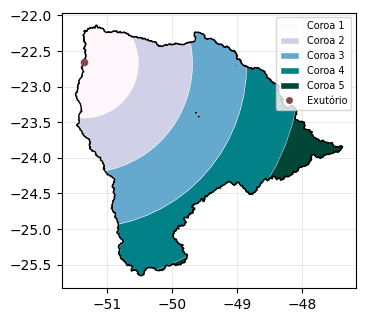

In [10]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib import colormaps
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator, FuncFormatter

cm = 1/2.54

bacias = carregar_shapefiles_bacias(SHAPEFILE_DIR, df_res)
nome = "CAPIVARA"
res = df_res[df_res["nome"] == nome].iloc[0]
geom_bacia = bacias[nome].geometry.union_all()
coroas = calcular_geometrias_coroas(
    geom_bacia, res["lat_dam"], res["lon_dam"], n_coroas=N_COROAS
)

fig, ax = plt.subplots(figsize=(9*cm, 9*cm), layout="constrained")
cmap = colormaps["PuBuGn"]
cores = [cmap((k - 1) / max(N_COROAS - 1, 1)) for k in range(1, N_COROAS + 1)]
for c, cor in zip(coroas, cores):
    if c is not None and not c.is_empty:
        gpd.GeoSeries([c], crs="EPSG:4326").plot(ax=ax, color=cor, edgecolor="white", linewidth=0.3)
gpd.GeoSeries([geom_bacia], crs="EPSG:4326").boundary.plot(ax=ax, color="black", linewidth=1)
ax.scatter([res["lon_dam"]], [res["lat_dam"]], c="#834949", s=20, zorder=5)

ax.set_axisbelow(True)
ax.grid(True, color="0.85", linewidth=0.4, zorder=0)

handles = [Patch(facecolor=cor, edgecolor="white", label=f"Coroa {k}") for k, cor in enumerate(cores, start=1)]
handles.append(Line2D([0], [0], marker="o", linestyle="none", markerfacecolor="#834949", markeredgecolor="white", markersize=6, label="Exutório"))
ax.legend(handles=handles, loc="upper right", frameon=True, fontsize=7)
plt.show()

## 2. Processar ET para cada reservatório

Lê os NetCDF anuais do ERA5-Land e extrai a ET média de cada coroa (mm/dia).

In [5]:
df = processar_coroas_et(
    era5_dir=ERA5_DIR,
    shapefile_dir=SHAPEFILE_DIR,
    data_inicio=INICIO,
    data_fim=FIM,
    n_coroas=N_COROAS,
    df_res=df_res,
)
print(df.shape)
df.head()

Carregando shapefiles das bacias...
Bacias carregadas: 32/32

Gerando 5 coroas por reservatório...
  14 DE JULHO: 5/5 coroas com interseção
  A. VERMELHA: 5/5 coroas com interseção
  B.COQUEIROS: 5/5 coroas com interseção
  BALBINA: 5/5 coroas com interseção
  BATALHA: 5/5 coroas com interseção
  CANOAS II: 5/5 coroas com interseção
  CAPIVARA: 5/5 coroas com interseção
  CASTRO ALVES: 5/5 coroas com interseção
  COLIDER: 5/5 coroas com interseção
  D. FRANCISCA: 5/5 coroas com interseção
  DARDANELOS: 5/5 coroas com interseção
  EMBORCAÃÃO: 5/5 coroas com interseção
  ESPORA: 5/5 coroas com interseção
  FOZ CHAPECO: 5/5 coroas com interseção
  G. P. SOUZA: 5/5 coroas com interseção
  GARIBALDI: 5/5 coroas com interseção
  IRAPE: 5/5 coroas com interseção
  ITAPEBI: 5/5 coroas com interseção
  ITÃ: 5/5 coroas com interseção
  JUPIA: 5/5 coroas com interseção
  P. COLOMBIA: 5/5 coroas com interseção
  PICADA: 5/5 coroas com interseção
  PORTO PRIMAVERA: 5/5 coroas com interseção
  RO

Processando ERA5-Land: 100%|██████████| 28/28 [8:12:39<00:00, 1055.69s/it]  


(9498, 160)


,14 DE JULHO_coroa1,14 DE JULHO_coroa2,14 DE JULHO_coroa3,14 DE JULHO_coroa4,14 DE JULHO_coroa5,A. VERMELHA_coroa1,A. VERMELHA_coroa2,A. VERMELHA_coroa3,A. VERMELHA_coroa4,A. VERMELHA_coroa5,...,BILLINGS_coroa1,BILLINGS_coroa2,BILLINGS_coroa3,BILLINGS_coroa4,BILLINGS_coroa5,PONTE NOVA_coroa1,PONTE NOVA_coroa2,PONTE NOVA_coroa3,PONTE NOVA_coroa4,PONTE NOVA_coroa5
data,,,,,,,,,,,,,,,,,,,,,
2000-01-01,2.919885,3.037694,3.364203,3.621580,4.542347,2.974832,2.727747,2.595573,2.454509,2.104045,...,3.551008,3.218264,3.005430,3.015990,3.147658,2.486958,2.712846,2.797512,2.573542,2.805307
2000-01-02,3.408282,3.345704,3.468019,3.498240,4.238196,3.481618,3.454176,2.541927,1.955257,1.986354,...,5.213614,4.976505,4.822405,4.777544,4.909250,2.745747,2.770471,2.835997,2.157977,2.449180
2000-01-03,2.861391,2.771668,2.920823,2.753333,2.693794,2.936390,2.428539,1.863512,1.825193,1.997703,...,5.075696,4.787191,4.600486,4.545755,4.719001,3.069136,2.760204,2.549518,1.967193,2.032515
2000-01-04,4.152430,3.816031,3.733348,3.913061,4.535817,2.596009,2.777406,3.088922,2.296889,2.060706,...,4.652535,4.579689,4.510328,4.402416,4.500295,1.873271,2.056951,1.996903,1.844721,2.140493
2000-01-05,4.666535,4.266514,4.119061,4.510999,5.288846,2.910640,2.959178,3.298975,3.412848,3.872209,...,4.656964,4.586542,4.443555,4.219442,4.198629,2.054440,2.468465,2.627934,3.150765,3.649619


## 3. Salvar e resumir

In [6]:
OUTPUT_CSV.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(OUTPUT_CSV, float_format="%.2f")

print(f"Dimensões: {df.shape[0]} dias × {df.shape[1]} colunas")
n_res = len(set(c.rsplit("_coroa", 1)[0] for c in df.columns))
pct_nan = 100 * df.isna().sum().sum() / (df.shape[0] * df.shape[1])
print(f"Reservatórios: {n_res} | Coroas por reservatório: {N_COROAS}")
print(f"NaN total: {pct_nan:.1f}%")
print(f"ET média (mm/dia): {df.mean().mean():.2f}  | min: {df.min().min():.2f}  max: {df.max().max():.2f}")

Dimensões: 9498 dias × 160 colunas
Reservatórios: 32 | Coroas por reservatório: 5
NaN total: 0.0%
ET média (mm/dia): 2.89  | min: 0.06  max: 7.90


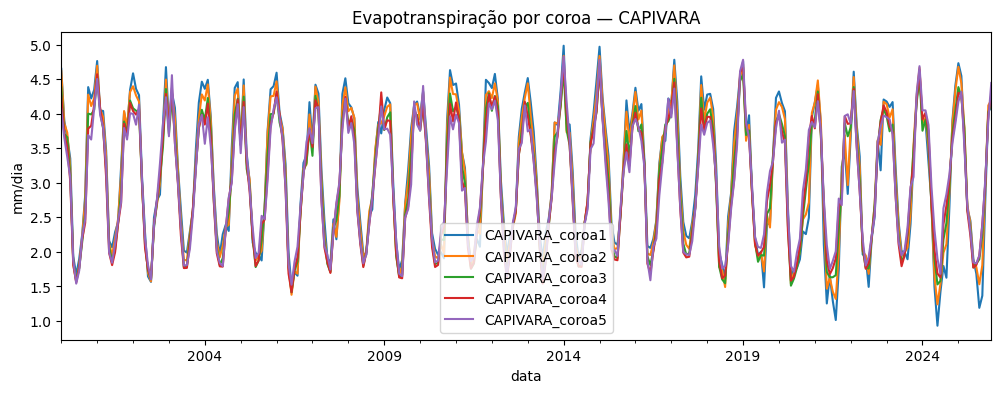

In [9]:
# Exemplo: série das 5 coroas de um reservatório (média mensal)
cols = [c for c in df.columns if c.startswith(nome + "_coroa")]
df[cols].resample("MS").mean().plot(figsize=(12, 4), title=f"Evapotranspiração por coroa — {nome}")
plt.ylabel("mm/dia")
plt.show()